## 1) Environment and validation configuration

This section sets the paths, the DIF-PI-compatible split parameters, and the saved SDG model settings used for validation.

# SDG validation notebook for DIF-PI

This notebook isolates the **validation stage** of the synthetic data generator used in DIF-PI.

## What this notebook does

1. loads the **dunnhumby / Complete Journey** panel exported by `eda-complete-journey.ipynb`;
2. reuses the **DIF-PI SKU split logic** to obtain consistent `TRAIN_SKUs`, `TEST_SKUs`, and `CASE_SKU`;
3. loads the saved SDG checkpoint from `artifacts/models/`;
4. generates synthetic futures for the case SKU and evaluation SKUs;
5. computes validation metrics and aggregate summaries.

## Expected input

- a previously trained SDG checkpoint under `artifacts/models/sdg_chronos_t5_small_dunnhumby`

Use `train-sdg.ipynb` first if the checkpoint does not exist yet.


In [1]:
from pathlib import Path
import json
import sys
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path('.').resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from src.sdg import LLMSyntheticTimeSeriesGenerator, compute_difpi_sku_split

# DIF-PI-aligned paths
PANEL_PATH = REPO_ROOT / 'datasets' / 'processed' / 'difpi_pricing_demand_panel.csv'
OUT_DIR = REPO_ROOT / 'artifacts' / 'sdg_validation'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Standardized columns
SKU_COL = 'StockCode'
TIME_COL = 'timestamp'
PRICE_COL = 'price'
DEMAND_COL = 'demand'

# DIF-PI protocol settings
ELIGIBILITY_MODE = "adaptive"
MIN_HISTORY_DAYS_STRICT = 365
MIN_NONZERO_DAYS_STRICT = 60
MIN_HISTORY_DAYS_RELAXED = 120
MIN_NONZERO_DAYS_RELAXED = 30
SKU_HOLDOUT_ENABLED = True
TEST_SKU_FRAC = 0.20
SPLIT_SEED = 42
CASE_SKU_OVERRIDE = None
TARGET_ELIGIBLE_FRACTION = 0.8
HORIZON = 30
TRANSFORMER_SEQ_LEN = 30

# SDG settings
MODEL_NAME = "amazon/chronos-t5-small"
SDG_MODEL_DIR = REPO_ROOT / 'artifacts' / 'models' / 'sdg_chronos_t5_small_dunnhumby'
LOAD_EXISTING_MODEL = True
RUN_TRAINING = False

CONTEXT_LENGTH = 140
PREDICTION_LENGTH = HORIZON
STRIDE = 1
MAX_TRAIN_SKUS = None
INCLUDE_METADATA = False   # no raw SKU token
NUM_RETURN_SEQUENCES = 10
SEASONALITY_STRENGTH = 0.75

# Training settings
TRAIN_STEPS = 1500
BATCH_SIZE = 2
LEARNING_RATE = 2.5e-5
LORA_RANK = 32
LORA_ALPHA = 64

# Aggregate evaluation
MAX_EVAL_TEST_SKUS = None

print("PLATFORM:", platform.platform())
print("PANEL_PATH:", PANEL_PATH)
print("OUT_DIR:", OUT_DIR)
print("MODEL_NAME:", MODEL_NAME)
print("SDG_MODEL_DIR:", SDG_MODEL_DIR)

PLATFORM: macOS-26.3.1-arm64-arm-64bit
PANEL_PATH: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/datasets/processed/difpi_pricing_demand_panel.csv
OUT_DIR: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/artifacts/sdg_validation
MODEL_NAME: amazon/chronos-t5-small
SDG_MODEL_DIR: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/artifacts/models/sdg_chronos_t5_small_dunnhumby


## 2) Data loading

The processed panel exported by `eda-complete-journey.ipynb` is loaded here. The notebook expects the same daily panel used across the DIF-PI experiments.

In [2]:
panel = pd.read_csv(PANEL_PATH)
panel[SKU_COL] = panel[SKU_COL].astype(str)
panel[TIME_COL] = pd.to_datetime(panel[TIME_COL], errors='raise')
panel = panel.sort_values([SKU_COL, TIME_COL]).reset_index(drop=True)

print(panel.shape)
display(panel.head())

(70490, 4)


,timestamp,StockCode,price,demand
0,2016-01-10,1003600,0.645,2.0
1,2016-01-11,1003600,0.645,0.0
2,2016-01-12,1003600,0.645,0.0
3,2016-01-13,1003600,0.645,0.0
4,2016-01-14,1003600,0.645,0.0


## 3) DIF-PI-consistent SKU split

This section computes eligibility, train-test SKU partitioning, and the case SKU using the same DIF-PI split logic so the SDG experiments remain consistent with the main framework.

In [3]:
split_info = compute_difpi_sku_split(
    panel_df=panel,
    sku_col=SKU_COL,
    time_col=TIME_COL,
    target_col=DEMAND_COL,
    eligibility_mode=ELIGIBILITY_MODE,
    min_history_days_strict=MIN_HISTORY_DAYS_STRICT,
    min_nonzero_days_strict=MIN_NONZERO_DAYS_STRICT,
    min_history_days_relaxed=MIN_HISTORY_DAYS_RELAXED,
    min_nonzero_days_relaxed=MIN_NONZERO_DAYS_RELAXED,
    transformer_seq_len=TRANSFORMER_SEQ_LEN,
    horizon=HORIZON,
    target_eligible_fraction=TARGET_ELIGIBLE_FRACTION,
    sku_holdout_enabled=SKU_HOLDOUT_ENABLED,
    test_sku_frac=TEST_SKU_FRAC,
    split_seed=SPLIT_SEED,
    case_sku_override=CASE_SKU_OVERRIDE,
)

sku_stats = split_info["sku_stats"]
eligible = split_info["eligible"]
TRAIN_SKUs = split_info["train_skus"]
TEST_SKUs = split_info["test_skus"]
CASE_SKU = split_info["case_sku"]

print(f"Eligibility mode: {ELIGIBILITY_MODE}")
print(f"Thresholds used: MIN_HISTORY_DAYS={split_info['min_history_days']}, MIN_NONZERO_DAYS={split_info['min_nonzero_days']}")
print(f"Eligible SKUs: {len(eligible)} | Train SKUs: {len(TRAIN_SKUs)} | Test SKUs: {len(TEST_SKUs)}")
print("CASE_SKU selected:", CASE_SKU)

pd.Series(TRAIN_SKUs, name="train_sku").to_csv(OUT_DIR / "train_skus.csv", index=False)
pd.Series(TEST_SKUs, name="test_sku").to_csv(OUT_DIR / "test_skus.csv", index=False)

display(sku_stats.describe(percentiles=[.1,.25,.5,.75,.9]))
display(eligible.head())

Eligibility mode: adaptive
Thresholds used: MIN_HISTORY_DAYS=365, MIN_NONZERO_DAYS=60
Eligible SKUs: 100 | Train SKUs: 80 | Test SKUs: 20
CASE_SKU selected: 1070820


,history_days,nonzero_days
count,100.000000,100.000000
mean,704.900000,603.580000
std,11.318618,112.013994
min,632.000000,112.000000
10%,700.900000,524.600000
25%,705.000000,575.000000
50%,708.000000,621.500000
75%,710.000000,678.250000
90%,711.000000,694.100000
max,711.000000,708.000000


,StockCode,history_days,nonzero_days
0,1082185,711,708
1,1029743,710,708
2,1106523,711,705
3,981760,711,705
4,995242,709,703


## 4) Load saved SDG model

The SDG model checkpoint is loaded from disk and used for inference only. This notebook does not retrain the model.

In [4]:
train_skus_used = list(TRAIN_SKUs)
if MAX_TRAIN_SKUS is not None:
    train_skus_used = train_skus_used[:int(MAX_TRAIN_SKUS)]

sdg = LLMSyntheticTimeSeriesGenerator(
    model_name=MODEL_NAME,
    context_length=CONTEXT_LENGTH,
    prediction_length=PREDICTION_LENGTH,
    learning_rate=LEARNING_RATE,
    train_steps=TRAIN_STEPS,
    lora_rank=LORA_RANK,
    lora_alpha=LORA_ALPHA,
    batch_size=BATCH_SIZE,
    seasonality_strength=SEASONALITY_STRENGTH,
)

MODEL_STATUS = "not_loaded"
MODEL_READY = False
MODEL_BACKEND = "unknown"
TRANSFORMERS_VERSION = None

try:
    import transformers
    TRANSFORMERS_VERSION = transformers.__version__
except Exception:
    TRANSFORMERS_VERSION = "not_available"

print("TRANSFORMERS_VERSION:", TRANSFORMERS_VERSION)

def _safe_load_sdg_checkpoint(model_dir):
    """Load either a full saved model or a PEFT/LoRA adapter checkpoint."""
    model_dir = Path(model_dir)
    cfg_path = model_dir / "sdg_config.json"
    if not cfg_path.exists():
        raise FileNotFoundError(f"Missing SDG config: {cfg_path}")

    config = json.loads(cfg_path.read_text(encoding="utf-8"))
    obj = LLMSyntheticTimeSeriesGenerator(
        model_name=str(config.get("base_model_id") or config.get("model_name") or MODEL_NAME),
        context_length=int(config.get("context_length", CONTEXT_LENGTH)),
        prediction_length=int(config.get("prediction_length", PREDICTION_LENGTH)),
        num_bins=int(config.get("num_bins", 4094)),
        value_range=tuple(config.get("value_range", [-5.0, 5.0])),
        learning_rate=float(config.get("learning_rate", LEARNING_RATE)),
        train_steps=int(config.get("train_steps", TRAIN_STEPS)),
        lora_rank=int(config.get("lora_rank", LORA_RANK)),
        lora_alpha=int(config.get("lora_alpha", LORA_ALPHA)),
        batch_size=int(config.get("batch_size", BATCH_SIZE)),
        max_source_length=int(config.get("max_source_length", 768)),
        max_target_length=int(config.get("max_target_length", 256)),
        random_state=int(config.get("random_state", 42)),
        task_prefix=str(config.get("task_prefix", "generate synthetic retail demand future from historical context")),
        seasonality_strength=float(config.get("seasonality_strength", SEASONALITY_STRENGTH)),
    )

    from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    adapter_cfg_path = model_dir / "adapter_config.json"
    base_model_id = str(config.get("base_model_id") or config.get("model_name") or MODEL_NAME)

    if adapter_cfg_path.exists():
        from peft import PeftModel
        base_model = AutoModelForSeq2SeqLM.from_pretrained(base_model_id)
        # The tokenizer may have been resized during fine-tuning.
        try:
            try:
                base_model.resize_token_embeddings(len(tokenizer), mean_resizing=False)
            except TypeError:
                # Backward compatibility with older transformers versions.
                base_model.resize_token_embeddings(len(tokenizer))
        except Exception:
            pass
        model = PeftModel.from_pretrained(base_model, model_dir)
        backend_name = config.get("backend_name") or "lora"
    else:
        model = AutoModelForSeq2SeqLM.from_pretrained(model_dir)
        backend_name = config.get("backend_name") or "loaded"

    obj.model = model
    obj.tokenizer = tokenizer
    obj.backend_name = str(backend_name)
    obj.is_peft_model = bool(adapter_cfg_path.exists())
    obj.config["model_name"] = str(model_dir)
    loaded_base = config.get("base_model_id")
    if loaded_base:
        obj.config["base_model_id"] = str(loaded_base)

    ti = model_dir / "training_info.json"
    if ti.exists():
        try:
            obj.training_info = json.loads(ti.read_text(encoding="utf-8"))
            if obj.training_info.get("backend_name"):
                obj.backend_name = str(obj.training_info.get("backend_name"))
        except Exception:
            pass

    return obj

try:
    if LOAD_EXISTING_MODEL and SDG_MODEL_DIR.exists():
        sdg = _safe_load_sdg_checkpoint(SDG_MODEL_DIR)
        MODEL_STATUS = "loaded_existing_checkpoint"
        MODEL_READY = True
        MODEL_BACKEND = getattr(sdg, "backend_name", "loaded")
    elif RUN_TRAINING:
        train_df = sdg.build_training_dataframe(
            panel_df=panel,
            sku_col=SKU_COL,
            time_col=TIME_COL,
            target_col=DEMAND_COL,
            train_skus=train_skus_used,
            per_sku_train_frac=1.0,
            stride=STRIDE,
            include_metadata=INCLUDE_METADATA,
        )
        rng = np.random.default_rng(42)
        idx = np.arange(len(train_df))
        rng.shuffle(idx)
        n_eval = max(1, int(round(0.1 * len(idx))))
        eval_idx = idx[:n_eval]
        tr_idx = idx[n_eval:]
        eval_df = train_df.iloc[eval_idx].reset_index(drop=True)
        train_df_fit = train_df.iloc[tr_idx].reset_index(drop=True)

        training_info = sdg.fit(
            train_df=train_df_fit,
            eval_df=eval_df,
            output_dir=str(SDG_MODEL_DIR),
            logging_steps=25,
            save_steps=max(100, TRAIN_STEPS // 2),
        )
        sdg.save(
            output_dir=str(SDG_MODEL_DIR),
            push_to_hub=False,
        )
        MODEL_STATUS = "trained_and_saved"
        MODEL_READY = True
        MODEL_BACKEND = training_info.get("backend_name", getattr(sdg, "backend_name", "unknown"))
    else:
        MODEL_STATUS = "checkpoint_missing_local_dir" if not SDG_MODEL_DIR.exists() else "not_loaded"
        MODEL_READY = False
        MODEL_BACKEND = "unknown"
except Exception as exc:
    MODEL_STATUS = f"training_failed: {exc}"
    MODEL_READY = False
    MODEL_BACKEND = "unknown"
    raise

print("MODEL_STATUS:", MODEL_STATUS)
print("MODEL_READY:", MODEL_READY)
print("MODEL_BACKEND:", MODEL_BACKEND)
if not MODEL_READY:
    print("The notebook can still run the split / data cells, but generation requires a saved checkpoint or RUN_TRAINING=True.")

TRANSFORMERS_VERSION: 5.3.0


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

MODEL_STATUS: loaded_existing_checkpoint
MODEL_READY: True
MODEL_BACKEND: lora


## 5) Case-SKU reconstruction example

A time-based holdout is created for the selected `CASE_SKU` and used to build the local reconstruction example.

Decision date: 2017-11-12 | Train days: 679 | Test days: 30


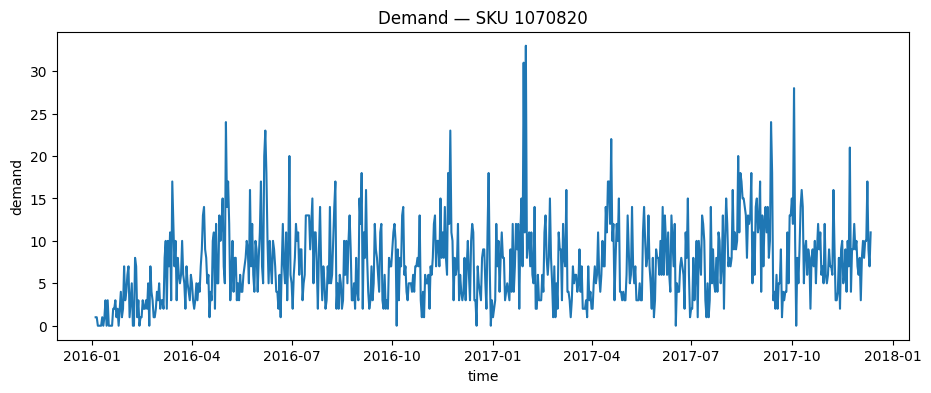

In [5]:
def make_daily_series(df, sku):
    g = df[df[SKU_COL].astype(str) == str(sku)].copy()
    g = g.sort_values(TIME_COL).set_index(TIME_COL)
    full = pd.date_range(g.index.min(), g.index.max(), freq='D')
    g = g.reindex(full)
    g.index.name = TIME_COL
    if PRICE_COL in g.columns:
        g[PRICE_COL] = g[PRICE_COL].ffill()
    g[DEMAND_COL] = g[DEMAND_COL].fillna(0.0)
    g = g.reset_index()
    return g

case_df = make_daily_series(panel, CASE_SKU)
DECISION_DATE = case_df[TIME_COL].max() - pd.Timedelta(days=HORIZON)
case_train = case_df[case_df[TIME_COL] <= DECISION_DATE].copy()
case_test = case_df[case_df[TIME_COL] > DECISION_DATE].copy()

print(f"Decision date: {DECISION_DATE.date()} | Train days: {len(case_train)} | Test days: {len(case_test)}")

plt.figure(figsize=(11, 4))
plt.plot(case_df[TIME_COL], case_df[DEMAND_COL])
plt.title(f'Demand — SKU {CASE_SKU}')
plt.xlabel('time'); plt.ylabel('demand')
plt.show()

## 6) Synthetic future generation

Multiple futures are sampled from the saved SDG model and the best candidate is selected with the notebook scoring rule.

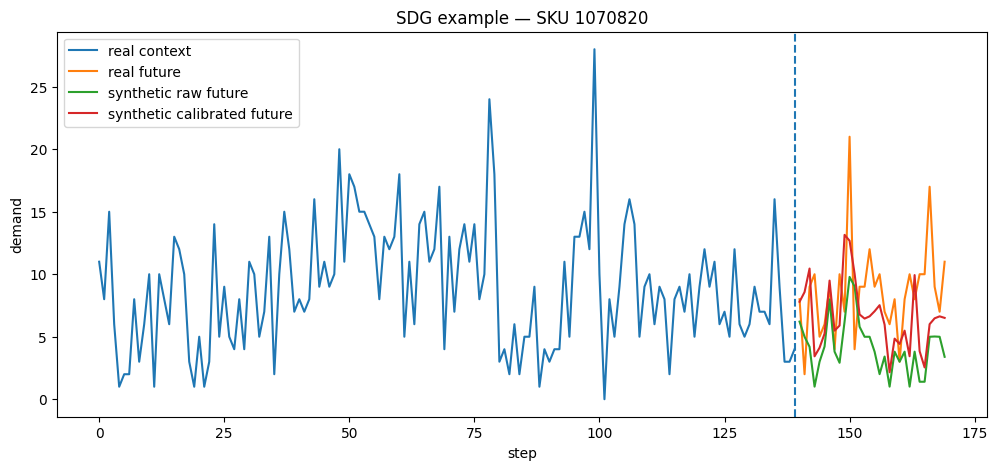

,candidate_index,score
0,5,1.842812
1,3,1.887570
2,9,1.899770
3,4,1.904860
4,8,1.932470
5,1,1.999305
6,0,2.062309
7,7,2.316407
8,2,2.322237
9,6,3.979929


In [6]:
if MODEL_READY:
    context_values = case_train[DEMAND_COL].astype(float).values[-CONTEXT_LENGTH:]
    context_dates = case_train[TIME_COL].iloc[-CONTEXT_LENGTH:].tolist()
    future_dates = case_test[TIME_COL].iloc[:PREDICTION_LENGTH].tolist()
    real_future = case_test[DEMAND_COL].astype(float).values[:PREDICTION_LENGTH]

    gen_out = sdg.generate(
        context_values=context_values,
        horizon=PREDICTION_LENGTH,
        metadata=None,
        num_return_sequences=NUM_RETURN_SEQUENCES,
        do_sample=True,
        temperature=0.9,
        top_p=0.95,
        context_dates=context_dates,
        future_dates=future_dates,
        apply_seasonal_calibration=True,
    )

    best_future = np.asarray(gen_out["best_future"], dtype=float)
    best_raw_future = np.asarray(gen_out["best_raw_future"], dtype=float)

    x_context = np.arange(len(context_values))
    x_future = np.arange(len(context_values), len(context_values) + len(real_future))

    plt.figure(figsize=(12, 5))
    plt.plot(x_context, context_values, label='real context')
    plt.plot(x_future, real_future, label='real future')
    plt.plot(x_future, best_raw_future, label='synthetic raw future')
    plt.plot(x_future, best_future, label='synthetic calibrated future')
    plt.axvline(len(context_values) - 1, linestyle='--')
    plt.title(f'SDG example — SKU {CASE_SKU}')
    plt.xlabel('step'); plt.ylabel('demand')
    plt.legend()
    plt.show()

    candidate_df = pd.DataFrame({
        "candidate_index": list(range(len(gen_out["candidate_scores"]))),
        "score": gen_out["candidate_scores"],
    }).sort_values("score").reset_index(drop=True)
    display(candidate_df.head(10))
else:
    print("Model is not ready. Set RUN_TRAINING=True or place a checkpoint under SDG_MODEL_DIR.")


## 7) Validation metrics

This section defines the validation functions used in the experiments.

In [7]:
from scipy.spatial.distance import jensenshannon
from scipy.stats import wasserstein_distance
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity


def lag_acf(values, lag):
    x = np.asarray(values, dtype=float).ravel()
    if len(x) <= lag or lag <= 0:
        return 0.0
    x1 = x[:-lag]
    x2 = x[lag:]
    if np.std(x1) < 1e-8 or np.std(x2) < 1e-8:
        return 0.0
    return float(np.corrcoef(x1, x2)[0, 1])


def summarize_windows(windows):
    flat = np.asarray(windows, dtype=float).ravel()
    return {
        'mean': float(np.mean(flat)),
        'std': float(np.std(flat)),
        'median': float(np.median(flat)),
        'zero_share': float(np.mean(flat == 0)),
        'lag1_acf': float(lag_acf(flat, 1)),
        'lag7_acf': float(lag_acf(flat, 7)),
    }


def js_distance_from_hist(real_vals, syn_vals, bins=30):
    lo = min(float(np.min(real_vals)), float(np.min(syn_vals)))
    hi = max(float(np.max(real_vals)), float(np.max(syn_vals)))
    if hi <= lo:
        return 0.0
    h1, edges = np.histogram(real_vals, bins=bins, range=(lo, hi), density=True)
    h2, _ = np.histogram(syn_vals, bins=edges, density=True)
    h1 = h1 + 1e-12
    h2 = h2 + 1e-12
    h1 = h1 / h1.sum()
    h2 = h2 / h2.sum()
    return float(jensenshannon(h1, h2))


def tstr_trts_metrics(real_windows, syn_windows):
    real_windows = np.asarray(real_windows, dtype=float)
    syn_windows = np.asarray(syn_windows, dtype=float)
    if len(real_windows) < 4 or len(syn_windows) < 4:
        return {'tstr': {'mae': np.nan, 'rmse': np.nan}, 'trts': {'mae': np.nan, 'rmse': np.nan}}

    X_real = real_windows[:, :-1]
    y_real = real_windows[:, -1]
    X_syn = syn_windows[:, :-1]
    y_syn = syn_windows[:, -1]

    Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(X_real, y_real, test_size=0.3, random_state=42)
    Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(X_syn, y_syn, test_size=0.3, random_state=42)

    rf_tstr = RandomForestRegressor(n_estimators=200, random_state=42)
    rf_tstr.fit(Xs_tr, ys_tr)
    pred_tstr = rf_tstr.predict(Xr_te)

    rf_trts = RandomForestRegressor(n_estimators=200, random_state=42)
    rf_trts.fit(Xr_tr, yr_tr)
    pred_trts = rf_trts.predict(Xs_te)

    return {
        'tstr': {
            'mae': float(mean_absolute_error(yr_te, pred_tstr)),
            'rmse': float(np.sqrt(mean_squared_error(yr_te, pred_tstr))),
        },
        'trts': {
            'mae': float(mean_absolute_error(ys_te, pred_trts)),
            'rmse': float(np.sqrt(mean_squared_error(ys_te, pred_trts))),
        }
    }


def detection_auc(real_windows, syn_windows):
    X = np.vstack([real_windows, syn_windows])
    y = np.array([1] * len(real_windows) + [0] * len(syn_windows))
    if len(np.unique(y)) < 2 or len(X) < 10:
        return np.nan
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    clf = LogisticRegression(max_iter=1000)
    clf.fit(Xtr, ytr)
    proba = clf.predict_proba(Xte)[:, 1]
    return float(roc_auc_score(yte, proba))


def privacy_proxy(real_windows, syn_windows):
    real = np.asarray(real_windows, dtype=float)
    syn = np.asarray(syn_windows, dtype=float)
    def pairwise_min_mean(A, B):
        d = ((A[:, None, :] - B[None, :, :]) ** 2).sum(axis=2) ** 0.5
        return float(np.mean(np.min(d, axis=1)))
    syn_to_real = pairwise_min_mean(syn, real)
    real_to_real = pairwise_min_mean(real, real + 1e-12)
    ratio = syn_to_real / real_to_real if real_to_real > 1e-8 else np.nan
    return {
        'syn_to_real_mean_min_dist': syn_to_real,
        'real_to_real_mean_min_dist': real_to_real,
        'nn_distance_ratio': ratio,
    }

## 8) Multi-SKU evaluation

The saved model is evaluated on the test SKUs using time-based holdouts.

Evaluated test SKUs: 20


,sku,mae,rmse,candidate_score
0,1085604,1.911303,2.291847,1.115454
1,1081177,2.358490,3.218013,1.241468
2,1127831,2.968841,3.452833,1.386886
3,986912,2.640958,3.515076,1.273661
4,1092026,3.063513,4.011235,1.463744
5,847270,3.052101,4.224919,1.265250
6,866211,3.682086,4.303409,1.380488
7,962568,3.281651,4.555407,1.097822
8,834484,4.015701,4.892195,0.973961
9,1050229,3.275362,5.026479,1.256758


{
  "real_summary": {
    "mean": 176.66166666666666,
    "std": 1349.4118819682974,
    "median": 5.0,
    "zero_share": 0.155,
    "lag1_acf": 0.06821088194018826,
    "lag7_acf": 0.03364854124737079
  },
  "synthetic_summary": {
    "mean": 144.58442510752542,
    "std": 1241.177157682377,
    "median": 5.64330030248764,
    "zero_share": 0.07833333333333334,
    "lag1_acf": 0.018643726443087587,
    "lag7_acf": 0.8574599590340982
  },
  "wasserstein_distance": 66.5210308844476,
  "avg_cosine_similarity": 0.7044026182390671,
  "avg_jensen_shannon_distance": 0.5554614014908896,
  "tstr": {
    "mae": 2211.4848957816826,
    "rmse": 5399.373924900004
  },
  "trts": {
    "mae": 516.1397661840043,
    "rmse": 637.4664324051248
  },
  "detection_auc": 0.5,
  "privacy_proxy": {
    "syn_to_real_mean_min_dist": 1928.0474541498181,
    "real_to_real_mean_min_dist": 5.553013393633783e-12,
    "nn_distance_ratio": NaN
  }
}


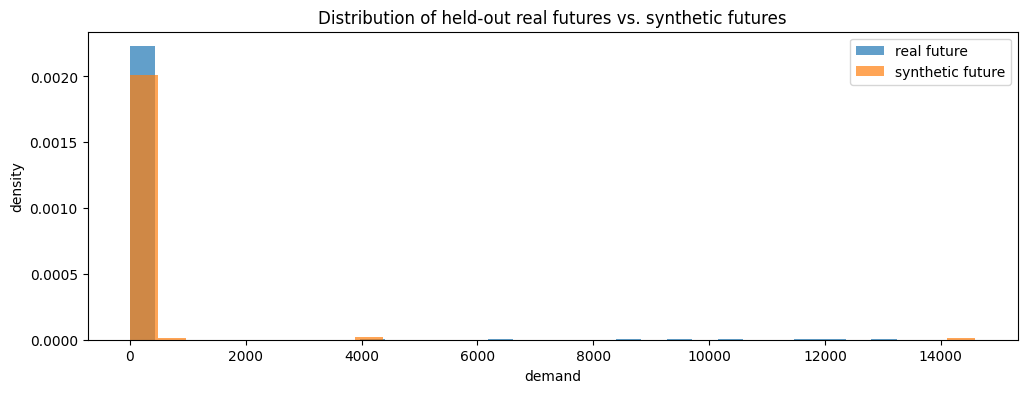

In [8]:
if MODEL_READY:
    eval_skus = list(TEST_SKUs)
    if MAX_EVAL_TEST_SKUS is not None:
        eval_skus = eval_skus[:int(MAX_EVAL_TEST_SKUS)]

    real_windows = []
    syn_windows = []
    rows = []

    for sku in eval_skus:
        sku_df = make_daily_series(panel, sku)
        decision_date = sku_df[TIME_COL].max() - pd.Timedelta(days=HORIZON)
        sku_train = sku_df[sku_df[TIME_COL] <= decision_date].copy()
        sku_test = sku_df[sku_df[TIME_COL] > decision_date].copy()

        if len(sku_train) < CONTEXT_LENGTH or len(sku_test) < PREDICTION_LENGTH:
            continue

        context_values = sku_train[DEMAND_COL].astype(float).values[-CONTEXT_LENGTH:]
        context_dates = sku_train[TIME_COL].iloc[-CONTEXT_LENGTH:].tolist()
        future_dates = sku_test[TIME_COL].iloc[:PREDICTION_LENGTH].tolist()
        real_future = sku_test[DEMAND_COL].astype(float).values[:PREDICTION_LENGTH]

        out = sdg.generate(
            context_values=context_values,
            horizon=PREDICTION_LENGTH,
            metadata=None,
            num_return_sequences=NUM_RETURN_SEQUENCES,
            do_sample=True,
            temperature=0.9,
            top_p=0.95,
            context_dates=context_dates,
            future_dates=future_dates,
            apply_seasonal_calibration=True,
        )
        syn_future = np.asarray(out["best_future"], dtype=float)

        real_windows.append(real_future)
        syn_windows.append(syn_future)

        rows.append({
            "sku": str(sku),
            "mae": float(mean_absolute_error(real_future, syn_future)),
            "rmse": float(np.sqrt(mean_squared_error(real_future, syn_future))),
            "candidate_score": float(out["candidate_scores"][out["best_index"]]),
        })

    eval_df = pd.DataFrame(rows).sort_values("rmse").reset_index(drop=True)
    print("Evaluated test SKUs:", len(eval_df))
    display(eval_df.head(20))

    real_arr = np.asarray(real_windows, dtype=float)
    syn_arr = np.asarray(syn_windows, dtype=float)

    metrics = {
        'real_summary': summarize_windows(real_arr),
        'synthetic_summary': summarize_windows(syn_arr),
        'wasserstein_distance': float(wasserstein_distance(real_arr.ravel(), syn_arr.ravel())),
        'avg_cosine_similarity': float(np.mean([cosine_similarity(r.reshape(1, -1), s.reshape(1, -1))[0, 0] for r, s in zip(real_arr, syn_arr)])),
        'avg_jensen_shannon_distance': float(np.mean([js_distance_from_hist(r, s) for r, s in zip(real_arr, syn_arr)])),
    }
    metrics.update(tstr_trts_metrics(real_arr, syn_arr))
    metrics['detection_auc'] = detection_auc(real_arr, syn_arr)
    metrics['privacy_proxy'] = privacy_proxy(real_arr, syn_arr)

    print(json.dumps(metrics, indent=2))

    plt.figure(figsize=(12, 4))
    plt.hist(real_arr.ravel(), bins=30, alpha=0.7, density=True, label='real future')
    plt.hist(syn_arr.ravel(), bins=30, alpha=0.7, density=True, label='synthetic future')
    plt.title('Distribution of held-out real futures vs. synthetic futures')
    plt.xlabel('demand'); plt.ylabel('density')
    plt.legend()
    plt.show()

    eval_df.to_csv(OUT_DIR / "sdg_eval_per_sku.csv", index=False)
    (OUT_DIR / "sdg_eval_summary.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")
else:
    print("Model is not ready. Aggregate evaluation skipped.")